# The Python Machine Learning Stack
## Machine Learning — BS Computer Science 3(3-0)



| | |
|---|---|
| **Notebook** | `NB02_Python_ML_Stack.ipynb` |
| **Lecture** | Lecture 3 (Week 1) |
| **CLO** | CLO-1 / CLO-5 |
| **Dataset** | Iris, plus a real CSV of your choice |

**Objective.** Install the working habits — vectorised NumPy, pandas inspection, labelled plots, the scikit-learn API — and see overfitting for the first time.

**By the end of this notebook you will be able to:**

1. Use vectorised NumPy operations and explain the axis argument.
2. Perform the six-step first look at any dataset with pandas.
3. Produce fully labelled histograms and class-coloured scatter plots.
4. Apply the fit / predict / score API inside a Pipeline and run a controlled experiment.

---

## 0. Setup and reproducibility

In [1]:
# ---------------------------------------------------------------------
# Reproducibility header — required in EVERY notebook you submit
# ---------------------------------------------------------------------
import sys, numpy as np, pandas as pd, sklearn, matplotlib
import matplotlib.pyplot as plt

print('python      ', sys.version.split()[0])
print('numpy       ', np.__version__)
print('pandas      ', pd.__version__)
print('scikit-learn', sklearn.__version__)
print('matplotlib  ', matplotlib.__version__)

RANDOM_STATE = 1
rng = np.random.default_rng(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

plt.rcParams['figure.figsize'] = (8, 4.5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

python       3.13.15
numpy        2.1.3
pandas       2.2.3
scikit-learn 1.6.1
matplotlib   3.10.0


## 1. NumPy — vectorise, never loop

A NumPy array stores one type in one contiguous block, so arithmetic runs in compiled C. **`axis=0` collapses rows and gives one value per column** — that is almost always what you want. Mixing up the axis is the most common NumPy bug in student code.

In [2]:
big = rng.normal(size=(100_000, 20))

# Python loop
loop_time = %timeit -o -n 10 -r 3 np.array([big[:, j].mean() for j in range(big.shape[1])])

# Vectorised NumPy
vector_time = %timeit -o -n 10 -r 3 big.mean(axis=0)

ratio = loop_time.best / vector_time.best

print("Loop / vectorised speed ratio: %.2fx" % ratio)
print("Vectorisation computes the same column means more efficiently than repeatedly using a Python loop.")

7.46 ms ± 180 µs per loop (mean ± std. dev. of 3 runs, 10 loops each)
4.23 ms ± 429 µs per loop (mean ± std. dev. of 3 runs, 10 loops each)
Loop / vectorised speed ratio: 2.00x
Vectorisation computes the same column means more efficiently than repeatedly using a Python loop.


### Exercise 1.1 — loop versus vectorised

Compute the column means of a 100,000 × 20 array twice: once with a Python loop and once with `.mean(axis=0)`. Time both with `%%timeit` and report the ratio.

In [3]:
big = rng.normal(size=(100_000, 20))

# Python loop
loop_time = %timeit -o -n 10 -r 3 np.array([big[:, j].mean() for j in range(big.shape[1])])

# Vectorised NumPy
vector_time = %timeit -o -n 10 -r 3 big.mean(axis=0)

ratio = loop_time.best / vector_time.best

print("Loop / vectorised speed ratio: %.2fx" % ratio)
print("Vectorisation computes the same column means more efficiently than repeatedly using a Python loop.")

7.55 ms ± 150 µs per loop (mean ± std. dev. of 3 runs, 10 loops each)
3.8 ms ± 230 µs per loop (mean ± std. dev. of 3 runs, 10 loops each)
Loop / vectorised speed ratio: 2.05x
Vectorisation computes the same column means more efficiently than repeatedly using a Python loop.


## 2. pandas — the six-step first look

Run these on a **real, messy CSV**, not on Iris. What you are hunting for: shape, missing values, impossible values, class balance and feature scales.

In [4]:
from sklearn.datasets import load_wine

wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

print(df.shape)                                   # 1. big enough?
display(df.head())                                # 2. always look
df.info()                                         # 3. dtypes, non-null
display(df.describe().T[['min', 'max', 'mean', 'std']].round(2))   # 4. impossible values?
print(df['target'].value_counts(normalize=True))  # 5. class balance
print(df.isnull().sum().sum(), 'missing values')  # 6. missingness

(178, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

,min,max,mean,std
alcohol,11.03,14.83,13.00,0.81
malic_acid,0.74,5.80,2.34,1.12
ash,1.36,3.23,2.37,0.27
alcalinity_of_ash,10.60,30.00,19.49,3.34
magnesium,70.00,162.00,99.74,14.28
total_phenols,0.98,3.88,2.30,0.63
flavanoids,0.34,5.08,2.03,1.00
nonflavanoid_phenols,0.13,0.66,0.36,0.12
proanthocyanins,0.41,3.58,1.59,0.57
color_intensity,1.28,13.00,5.06,2.32


target
1    0.398876
0    0.331461
2    0.269663
Name: proportion, dtype: float64
0 missing values


**Interpretation.** Look at the `min`/`max` column of `describe()`. Which two features have the most different scales, and by what factor? Which models from Week 3 onwards would that break?

>Proline and nonflavanoid phenols have the most different numerical scales. Their maximum values are 1680 and 0.66 respectively, so proline's maximum is about 2,545 times larger. This difference in scale can strongly affect distance-based models such as k-NN because larger-scale features can dominate the distance calculation.

## 3. Matplotlib — the four plots you will draw all semester

Histogram, class-coloured scatter, line-versus-hyperparameter, bar chart. **Every plot needs axis labels with units and a legend.** An unlabelled plot carries no information and earns no marks.

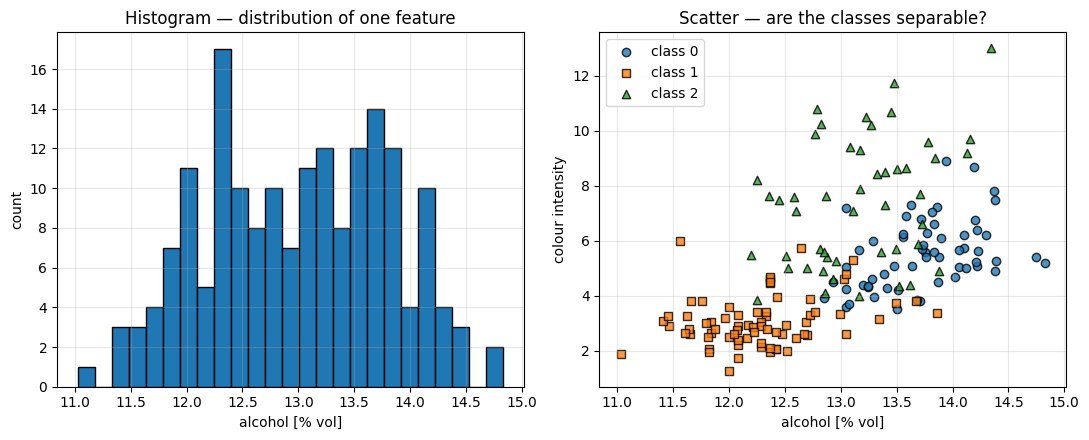

In [5]:
X, y = wine.data, wine.target

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

ax[0].hist(X[:, 0], bins=25, edgecolor='black')
ax[0].set_xlabel('alcohol [% vol]')
ax[0].set_ylabel('count')
ax[0].set_title('Histogram — distribution of one feature')

for cl, m in zip(np.unique(y), ('o', 's', '^')):
    ax[1].scatter(X[y == cl, 0], X[y == cl, 9], marker=m,
                  alpha=0.8, edgecolor='k', label=f'class {cl}')
ax[1].set_xlabel('alcohol [% vol]')
ax[1].set_ylabel('colour intensity')
ax[1].set_title('Scatter — are the classes separable?')
ax[1].legend()

plt.tight_layout(); plt.show()

## 4. Your first complete machine-learning program

Eleven lines. Every one of them corresponds to a concept from Lecture 2.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)

pipe = Pipeline([('scaler', StandardScaler()),
                 ('knn', KNeighborsClassifier(n_neighbors=5))])
pipe.fit(X_train, y_train)

print('train accuracy %.3f' % pipe.score(X_train, y_train))
print('test  accuracy %.3f' % pipe.score(X_test,  y_test))

train accuracy 0.960
test  accuracy 0.926


> **The most important line on this page.** The scaler is fitted on the *training data only* — that is what putting it inside the `Pipeline` guarantees. Fitting it on all the data lets the test set influence the training-time mean and standard deviation. That is **data leakage** and Week 8 is devoted to it.

## 5. Controlled experiment — change one thing at a time

Record the results in the table **before** you interpret anything. This is the standard experimental protocol for the rest of the course.

In [7]:
rows = []
for k in (1, 5, 25, 100):
    p = Pipeline([('scaler', StandardScaler()),
                  ('knn', KNeighborsClassifier(n_neighbors=k))])
    p.fit(X_train, y_train)
    rows.append({'variant': 'scaled',   'k': k,
                 'train': p.score(X_train, y_train),
                 'test':  p.score(X_test,  y_test)})

    raw = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
    rows.append({'variant': 'unscaled', 'k': k,
                 'train': raw.score(X_train, y_train),
                 'test':  raw.score(X_test,  y_test)})

results = pd.DataFrame(rows).pivot(index='k', columns='variant',
                                   values=['train', 'test']).round(3)
display(results)

train            test         
variant scaled unscaled scaled unscaled
k                                      
1        1.000    1.000  0.981    0.759
5        0.960    0.782  0.926    0.648
25       0.968    0.758  0.926    0.630
100      0.500    0.669  0.574    0.630

### Interpretation — three things to explain

1. At `k = 1` the **training** accuracy is exactly 1.000. Why is that guaranteed, and what does the number tell you about the model?
2. What happened when you removed the scaler, and why does k-NN care about units?
3. What happens to the test accuracy as `k` approaches the size of the training set?

> 1. At k = 1, each training point is its own nearest neighbour, so the model predicts the training label correctly and the training accuracy is guaranteed to be 1.000. This shows that k-NN with k = 1 can fit the training data extremely closely and may overfit.

2. Removing the scaler made the test accuracy much worse. For k = 5, for example, scaled test accuracy was 0.926 while unscaled test accuracy was 0.648. k-NN uses distances, so features with larger numerical units, such as proline, can dominate the distance calculation when the features are not scaled.

3. As k approaches the size of the training set, the model uses many training points to make each prediction. The test accuracy decreases because the model becomes too simple and can underfit the data. In our results, k = 100 gave much lower test accuracy than k = 5 or k = 25.

---
## Deliverable

The timing exercise (1.1), the six-step first look on a real CSV, two fully labelled plots, and the four-row results table with all three interpretations written out.

---
## Submission checklist

Tick every box before you submit. Items 1–6 are the course reproducibility
rules from Lecture 3 and are marked in the rubric.

- [ ] The random seed is fixed **and printed**
- [ ] Library versions are printed in the first cell
- [ ] The raw data file was **not** modified
- [ ] Preprocessing happens **after** the split, inside a `Pipeline`
- [ ] The dataset source and licence are stated in a markdown cell
- [ ] **Kernel → Restart & Run All** completes without error
- [ ] Every experiment is followed by a written interpretation
- [ ] At least one wrong prediction or failure case is explained
- [ ] Results are reported as **mean ± standard deviation** where cross-validated
- [ ] Every plot has axis labels with units and a legend
